<a href="https://colab.research.google.com/github/Ash100/Protein-Language-Models-Predict-LXXLL-Viral-Motifs-/blob/main/Embeddings_ESM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESM2 Embedding, Dimensionality Reduction, and Clustering of Viral LXXLL Motifs

**Part of:** *Protein Language Models Predict Candidate Viral Coactivator-Mimicking Motifs Targeting the
Androgen and Estrogen Receptors: An In Silico Study*

This notebook performs **Stage 2** of the analysis pipeline. It takes the 25-residue LXXLL-centred motif
windows produced in the motif-search stage (see `Viral_Protein_Motif_Search.ipynb` /
`data/motif_dataset.csv` in this repository — 355 viral windows plus the 7 host coactivator control motifs),
embeds them using the **ESM2** protein language model, projects the embeddings into 2D with **UMAP**,
benchmarks several clustering algorithms, and identifies viral motifs that occupy the same embedding-space
neighborhood as known nuclear receptor coactivator motifs (NCOA1–4, CBP, MED1, PGC1α).

## What this notebook does

1. **Embed** each motif window with `ESM2-t33_650M_UR50D` (mean-pooled final-layer representation).
2. **Reduce dimensionality** with UMAP (`n_neighbors=10`, `min_dist=0.1`, cosine metric).
3. **Benchmark clustering algorithms** (KMeans, Agglomerative, Spectral, DBSCAN, HDBSCAN) using Silhouette,
   Davies-Bouldin, and Calinski-Harabasz scores — see `Supplementary_Table__1.csv` in this repository for
   the resulting benchmark table. **Spectral Clustering** was selected as the best-performing method
   (highest Silhouette score) and is the clustering used for the results reported in the manuscript.
4. **Compare control vs. candidate motifs** within clusters (per-motif and per-cluster silhouette analysis,
   Mann–Whitney U test).
5. **Rank candidates by cosine similarity to control motifs** in ESM2 embedding space, and export per-cluster
   FASTA/CSV files for downstream structural modelling.

## Pipeline position

```
data/motif_dataset.csv (355 viral windows + 7 control motifs)
        │
        ▼
[THIS NOTEBOOK]  ESM2 embedding → UMAP → clustering benchmark → candidate filtering
        │
        ▼
Boltz-2 structural modelling vs. AR/ER LBDs  →  MM-GBSA binding free-energy ranking
```

## Requirements

- A GPU runtime is strongly recommended (the first cell checks for one via `nvidia-smi`).
- Python packages: `transformers`, `umap-learn`, `hdbscan`, `biopython`, `scikit-learn`, `matplotlib`,
  `seaborn`, `fair-esm`, `scipy`, `pandas`, `numpy`.
- Input: a FASTA file of motif windows (viral + control), referenced below as
  `ncbi_refseq_with_lxxll_motif_motif_patches.fasta`.

> **Path note:** file paths below use Google Colab's default `/content/...` convention. If running locally
> or on a different platform, update the `fasta_path` variable (and any other hardcoded paths) accordingly.

## ⚠️ Notes on this notebook's provenance

This notebook was used in an exploratory, iterative fashion during the study (visible in some duplicated and
superseded cells below, which have been documented in place rather than deleted, for transparency). Two
specific issues were identified and addressed during preparation of this public release:

1. **Two cells generate placeholder/synthetic data** (random cosine-similarity features, and a fully random
   embedding matrix written to `esm2_embeddings.csv`) that were used to scaffold/test downstream code before
   real data was available in that session. **These cells are disabled by default** (`RUN_DEMO_CELL = False`)
   so they cannot silently overwrite real results if the notebook is run top-to-bottom. They are clearly
   flagged in place below.
2. **Two file-path bugs** were found and fixed: a mismatched output folder name (cells that created
   `clusterwise_csv/` but wrote files to a differently-named `esm2_clusterwise_csv/` folder, which would
   raise an error), and a cell that read a file under a name (`final_top10_neighbors_with_clusters.csv`)
   different from the one actually written by the preceding cell (`top10_neighbors_with_clusters.csv`).

A remaining item that could not be resolved without author input is flagged in place (Step 3, below): several
downstream exploratory cells operate on a generic `labels` variable that is first assigned from **HDBSCAN**
clustering, whereas the clustering method reported in the manuscript as optimal (and used for the main
control-vs-candidate and cluster-export analyses later in this notebook) is **Spectral Clustering**. Please
confirm whether this was an intentional secondary comparison or should be aligned to Spectral clustering.


### Step 0 — Environment setup

Check for GPU availability and install required packages.

In [ ]:
# ✅ Enable GPU
!nvidia-smi

# ✅ Install dependencies
!pip install transformers umap-learn hdbscan biopython scikit-learn matplotlib seaborn fair-esm

### Step 1 — Load motif windows

Loads the FASTA file of 25-residue LXXLL motif windows (355 viral candidates + 7 host coactivator controls)
produced by the motif-search stage. Each FASTA record's `id` is used as the motif/protein identifier
throughout this notebook, and control motifs are later identified by matching their id against a fixed list
of prefixes (`NCOA1`, `NCOA2`, `NCOA3`, `NCOA4`, `CBP`, `MED1`, `PGC1`) — make sure the FASTA headers for
control sequences follow this naming convention.


In [ ]:
from Bio import SeqIO

fasta_path = "/content/ncbi_refseq_with_lxxll_motif_motif_patches.fasta"
motif_seqs = [(record.id, str(record.seq)) for record in SeqIO.parse(fasta_path, "fasta")]
print(f"Loaded {len(motif_seqs)} motifs")

Loaded 378 motifs


### Step 2 — Load the ESM2 protein language model

Loads `ESM2-t33_650M_UR50D` (650M-parameter model, 33 transformer layers) and its tokenizer/batch converter.

In [ ]:
import torch
from esm import pretrained

model, alphabet = pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

### Step 3 — Generate ESM2 embeddings

Runs each motif window through ESM2 in batches and mean-pools the final-layer (layer 33) token
representations (excluding the BOS/EOS tokens) to obtain a single fixed-length embedding vector per motif.


In [ ]:
embeddings = []

# Batch size can be tuned based on memory
batch_size = 32
for i in range(0, len(motif_seqs), batch_size):
    batch = motif_seqs[i:i+batch_size]
    labels, strs, tokens = batch_converter(batch)

    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=False)
    reps = results["representations"][33]

    for j, (_, seq) in enumerate(batch):
        emb = reps[j, 1:len(seq)+1].mean(0)  # mean pooling
        embeddings.append(emb.numpy())

### Step 4 — Dimensionality reduction (UMAP)

Projects the 1280-dimensional ESM2 embeddings into 2D using UMAP with cosine distance
(`n_neighbors=10`, `min_dist=0.1`, `random_state=42`). The 2D projection is used for both clustering and
visualization in the cells that follow.


In [ ]:
#@title Dimentionality Reduction
import umap
import numpy as np

X = np.array(embeddings)
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='cosine', random_state=42)
X_umap = reducer.fit_transform(X)

### Clustering Benchmark Script for ESM2 Embeddings

In [ ]:
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
import pandas as pd

### Step 5 — Clustering benchmark: imports and evaluation function

Defines the `evaluate_clustering` helper used to score each candidate clustering algorithm.

In [ ]:
#@title Evaluation Function
def evaluate_clustering(X, labels):
    unique = np.unique(labels)
    if len(unique) <= 1 or (len(unique) == 2 and -1 in unique):
        return {"Silhouette": None, "DB": None, "CH": None}
    return {
        "Silhouette": silhouette_score(X, labels),
        "DB": davies_bouldin_score(X, labels),
        "CH": calinski_harabasz_score(X, labels)
    }


In [ ]:
# Example: if you used UMAP
X_reduced = X_umap  # or whatever variable holds your reduced embeddings


### Step 6 — Run and benchmark five clustering algorithms

Fits KMeans, Agglomerative Clustering, Spectral Clustering, DBSCAN, and HDBSCAN on the UMAP-reduced
embeddings (`X_reduced = X_umap`), and scores each with Silhouette, Davies-Bouldin, and Calinski-Harabasz
metrics. The resulting benchmark table corresponds to `Supplementary_Table__1.csv` in this repository.


In [ ]:
#@title Run Clustering Methods
results = {}
labels_dict = {}

# KMeans
kmeans = KMeans(n_clusters=5, random_state=42).fit(X_reduced)
labels_dict["KMeans"] = kmeans.labels_
results["KMeans"] = evaluate_clustering(X_reduced, kmeans.labels_)

# Agglomerative
agglo = AgglomerativeClustering(n_clusters=5).fit(X_reduced)
labels_dict["Agglomerative"] = agglo.labels_
results["Agglomerative"] = evaluate_clustering(X_reduced, agglo.labels_)

# Spectral
spectral = SpectralClustering(n_clusters=5, assign_labels='discretize', random_state=42).fit(X_reduced)
labels_dict["Spectral"] = spectral.labels_
results["Spectral"] = evaluate_clustering(X_reduced, spectral.labels_)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X_reduced)
labels_dict["DBSCAN"] = dbscan.labels_
results["DBSCAN"] = evaluate_clustering(X_reduced, dbscan.labels_)

# HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=5).fit(X_reduced)
labels_dict["HDBSCAN"] = hdb.labels_
results["HDBSCAN"] = evaluate_clustering(X_reduced, hdb.labels_)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
#@title Display Result
df_results = pd.DataFrame(results).T
df_results = df_results.round(4)
print(df_results.sort_values("Silhouette", ascending=False))

/tmp/ipython-input-3203532850.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y=df_results["Silhouette"], palette="viridis")


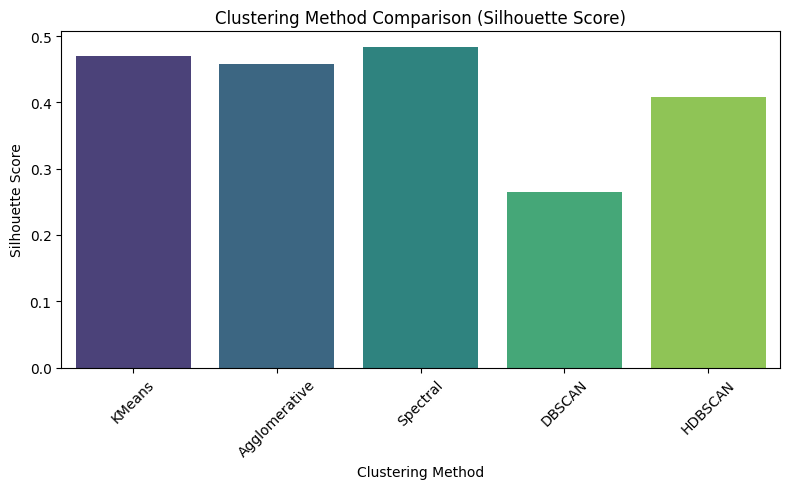

In [ ]:
#@title Cluster Bechmarkings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_results is your benchmark DataFrame
# Save to CSV
df_results.to_csv("clustering_benchmark.csv", index=True)

# Plot Silhouette scores
plt.figure(figsize=(8, 5))
sns.barplot(x=df_results.index, y=df_results["Silhouette"], palette="viridis")
plt.title("Clustering Method Comparison (Silhouette Score)")
plt.ylabel("Silhouette Score")
plt.xlabel("Clustering Method")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Benmarch_clustering_silhouette_scores.png", dpi=800)
plt.show()


### Step 7 — Select and visualize the best-performing method

Displays the benchmark table sorted by Silhouette score and visualizes the resulting clusters for the
top-ranked method. **Spectral Clustering** was selected on this basis and is the clustering used for the
control-vs-candidate and final cluster-export analyses later in this notebook, and for the results reported
in the manuscript.


In [ ]:
#@title Visualize Best Result
import matplotlib.pyplot as plt
import seaborn as sns

def plot_clusters(X, labels, title="Clustering Result"):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette="Spectral", s=30, legend=False)
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()

# Example: visualize best method
best_method = df_results["Silhouette"].idxmax()
plot_clusters(X_reduced, labels_dict[best_method], title=f"{best_method} Clustering")

### Secondary exploratory clustering pass (HDBSCAN)

> ⚠️ **Note for authors:** the cells below re-run **HDBSCAN** clustering directly on `X_umap` and assign the
> result to a generic `labels` variable. Several subsequent exploratory cells (per-motif/per-cluster
> silhouette analysis, nearest-neighbor computation, cluster-quality plots) use this `labels` variable rather
> than the **Spectral Clustering** labels (`labels_dict["Spectral"]`) used above and in the main
> control-vs-candidate overlay/analysis cells further below (and referenced in the manuscript as the
> clustering method used for the reported results). If this was intended as a deliberate secondary
> comparison across clustering methods, no change is needed — but if it was meant to reflect the same
> Spectral clustering as the main analysis, `labels` should be set to `labels_dict["Spectral"]` here instead
> of being recomputed with HDBSCAN. **This is flagged rather than silently changed, since it may affect the
> exact values shown in some exploratory figures below.**


In [ ]:
#@title Clustering (HDBSCAN)
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean')
labels = clusterer.fit_predict(X_umap)

In [ ]:
#@title Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=labels, palette='tab10', s=50)
plt.title("Motif Clustering via ESM-2 Embeddings + UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 8 — Compare control vs. candidate motifs within Spectral clusters

Visualizes the Spectral clustering result with control motifs overlaid as distinct markers, then computes
per-motif silhouette scores and compares control vs. candidate (non-control) motifs statistically
(Mann–Whitney U test) both overall and per cluster. This is the analysis supporting the manuscript's
observation that certain clusters are enriched for viral (candidate) motifs relative to host controls.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define control prefixes
control_prefixes = ("NCOA1", "NCOA2", "NCOA3", "NCOA4", "CBP", "MED1", "PGC1")

# Identify control nodes
is_control = np.array([any(name.startswith(prefix) for prefix in control_prefixes) for name, _ in motif_seqs])

# Use Spectral clustering labels
spectral_labels = labels_dict["Spectral"]

# Prepare plot
plt.figure(figsize=(10, 6))

# Get unique cluster labels (excluding noise -1)
unique_labels = sorted(set(spectral_labels) - {-1})
palette = sns.color_palette('tab10', n_colors=len(unique_labels))
label_to_color = {label: palette[i] for i, label in enumerate(unique_labels)}

# Plot non-control motifs by cluster
for label in unique_labels:
    idx = (spectral_labels == label) & (~is_control)
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        c=[label_to_color[label]],
        s=50,
        label=f"Cluster {label}",
        alpha=0.8
    )

# Plot noise cluster (-1) if present
if -1 in spectral_labels:
    idx = (spectral_labels == -1) & (~is_control)
    if np.any(idx):
        plt.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            c='lightgray',
            s=50,
            label="Noise",
            alpha=0.5
        )

# Overlay control motifs with same cluster color, distinct marker
for idx, (name, _) in enumerate(motif_seqs):
    label = spectral_labels[idx]
    if is_control[idx] and label != -1:
        plt.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            c=[label_to_color[label]],
            marker='X',
            s=100,
            edgecolors='black',
            linewidths=0.5
        )
    elif is_control[idx] and label == -1:
        plt.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            c='lightgray',
            marker='X',
            s=100,
            edgecolors='black',
            linewidths=0.5
        )

# Final touches
plt.title("Spectral Clustering of Motifs via ESM-2 Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save figure
plt.savefig("spectral_motif_clustering.png", dpi=800)
plt.show()


In [ ]:
#@title Score for Control Vs other motifs
from sklearn.metrics import silhouette_samples
import numpy as np
import pandas as pd

# ✅ Inputs
X = X_umap  # or your reduced embedding matrix
labels = labels_dict["Spectral"]  # cluster labels from Spectral Clustering
motif_names = [name for name, _ in motif_seqs]

# ✅ Compute silhouette scores per motif
sil_scores = silhouette_samples(X, labels)

# ✅ Define control prefixes
control_prefixes = ("NCOA1", "NCOA2", "NCOA3", "NCOA4", "CBP", "MED1", "PGC1")

# ✅ Identify control vs candidate
is_control = np.array([any(name.startswith(prefix) for prefix in control_prefixes) for name in motif_names])

# ✅ Create DataFrame
df_sil = pd.DataFrame({
    "Motif": motif_names,
    "Cluster": labels,
    "Silhouette": sil_scores,
    "Type": ["Control" if ctrl else "Candidate" for ctrl in is_control]
})

# ✅ Compute group means
mean_control = df_sil[df_sil["Type"] == "Control"]["Silhouette"].mean()
mean_candidate = df_sil[df_sil["Type"] == "Candidate"]["Silhouette"].mean()

print(f"✅ Mean Silhouette Score — Control motifs: {mean_control:.4f}")
print(f"✅ Mean Silhouette Score — Candidate motifs: {mean_candidate:.4f}")

# ✅ Optional: Save full scores
df_sil.to_csv("motif_silhouette_scores.csv", index=False)


In [ ]:
#@title 1. Mann–Whitney U Test: Control vs Candidate Silhouette Scores
from scipy.stats import mannwhitneyu

# ✅ Split scores
control_scores = df_sil[df_sil["Type"] == "Control"]["Silhouette"]
candidate_scores = df_sil[df_sil["Type"] == "Candidate"]["Silhouette"]

# ✅ Mann–Whitney U test (non-parametric)
stat, p_value = mannwhitneyu(control_scores, candidate_scores, alternative="two-sided")

print(f"🧪 Mann–Whitney U test:")
print(f"  U-statistic = {stat:.2f}")
print(f"  p-value     = {p_value:.4e}")
if p_value < 0.05:
    print("  ✅ Significant difference between Control and Candidate motifs.")
else:
    print("  ❌ No significant difference detected.")


In [ ]:
#@title Cluster Level Pattern
# Example: loop over clusters
for cluster_id in df_sil["Cluster"].unique():
    subset = df_sil[df_sil["Cluster"] == cluster_id]
    if subset["Type"].nunique() == 2 and len(subset) >= 6:
        stat, p = mannwhitneyu(
            subset[subset["Type"] == "Control"]["Silhouette"],
            subset[subset["Type"] == "Candidate"]["Silhouette"],
            alternative="two-sided"
        )
        print(f"Cluster {cluster_id}: p = {p:.4f}")


In [ ]:
#@title Per-Cluster Silhouette Analysis by Motif Type
# ✅ Group by cluster and motif type
cluster_stats = df_sil.groupby(["Cluster", "Type"])["Silhouette"].agg(["mean", "count"]).unstack()

# ✅ Optional: filter clusters with ≥3 motifs per group
valid_clusters = cluster_stats["count"][(cluster_stats["count"] >= 3).all(axis=1)].index

# ✅ Display mean silhouette scores per cluster
print("🔍 Per-cluster mean silhouette scores:")
print(cluster_stats["mean"].loc[valid_clusters].round(3))


🔍 Per-cluster mean silhouette scores:
Type     Candidate  Control
Cluster                    
1            0.566    0.573
2            0.305    0.405


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Prepare DataFrame
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["Silhouette"] = df_sil["Silhouette"]
df_umap["Type"] = df_sil["Type"]

# ✅ Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2", hue="Silhouette", style="Type",
                palette="coolwarm", edgecolor="black", s=60)
plt.title("UMAP Overlay: Silhouette Scores by Motif Type")
plt.legend(loc="best", bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.tight_layout()
plt.savefig("umap_silhouette_overlay.png", dpi=600)
plt.show()


> The next few cells repeat similar cluster-quality computations (evaluation, nearest neighbors, silhouette
> samples, centroid distances) on the generic `labels` variable from the secondary HDBSCAN pass noted above,
> and build a per-motif metadata table (`esm2_motif_metadata.csv`). The cell immediately after that duplicates
> this table construction without changes and can be skipped; it is left in place for transparency about the
> original analysis history.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define control prefixes
control_prefixes = ("NCOA1", "NCOA2", "NCOA3", "NCOA4", "CBP", "MED1", "PGC1")

# Identify control nodes
is_control = np.array([any(name.startswith(prefix) for prefix in control_prefixes) for name, _ in motif_seqs])

# Prepare plot
plt.figure(figsize=(10, 6))

# Get unique cluster labels (excluding noise -1)
unique_labels = sorted(set(labels) - {-1})
palette = sns.color_palette('tab10', n_colors=len(unique_labels))
label_to_color = {label: palette[i] for i, label in enumerate(unique_labels)}

# Plot non-control motifs by cluster
for label in unique_labels:
    idx = (labels == label) & (~is_control)
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        c=[label_to_color[label]],
        s=50,
        label=f"Cluster {label}",
        alpha=0.8
    )

# Plot noise cluster (-1) if present
if -1 in labels:
    idx = (labels == -1) & (~is_control)
    if np.any(idx):
        plt.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            c='lightgray',
            s=50,
            label="Noise",
            alpha=0.5
        )

# Overlay control motifs with same cluster color, distinct marker
for idx, (name, _) in enumerate(motif_seqs):
    if is_control[idx] and labels[idx] != -1:
        plt.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            c=[label_to_color[labels[idx]]],
            marker='X',
            s=100,
            edgecolors='black',
            linewidths=0.5
        )
    elif is_control[idx] and labels[idx] == -1:
        plt.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            c='lightgray',
            marker='X',
            s=100,
            edgecolors='black',
            linewidths=0.5
        )

# Final touches
plt.title("Motif Clustering via ESM-2 Embeddings + UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save figure
plt.savefig("esm2_motif_clustering.png", dpi=800)
plt.show()

In [ ]:
#@title Evaluate Clustering Quality
from sklearn.metrics import silhouette_score, davies_bouldin_score

valid_idx = labels != -1
print("Silhouette Score:", silhouette_score(X_umap[valid_idx], labels[valid_idx]))
print("Davies-Bouldin Index:", davies_bouldin_score(X_umap[valid_idx], labels[valid_idx]))

Silhouette Score: 0.48292395
Davies-Bouldin Index: 0.4755420462188944


In [ ]:
#@title Compute Nearest Neighbours
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=5, metric='euclidean')
nn_model.fit(X_umap)
distances, indices = nn_model.kneighbors(X_umap)

In [ ]:
#@title Compute Silhouette Scores (per motif)
from sklearn.metrics import silhouette_samples

valid_idx = labels != -1
sil_scores = np.full(len(labels), np.nan)
sil_scores[valid_idx] = silhouette_samples(X_umap[valid_idx], labels[valid_idx])


In [ ]:
#@title Compute Cluster Centroids & Distances
from scipy.spatial.distance import euclidean

centroids = {}
for label in np.unique(labels):
    if label == -1:
        continue
    centroids[label] = X_umap[labels == label].mean(axis=0)

dist_to_centroid = [
    euclidean(X_umap[i], centroids[labels[i]]) if labels[i] != -1 else np.nan
    for i in range(len(labels))
]

In [ ]:
# ⚠️ NOT PART OF THE PUBLISHED ANALYSIS — SYNTHETIC/PLACEHOLDER DATA ONLY.
# This cell uses randomly generated `motif_features` (np.random.rand) as a stand-in
# for real per-motif features, purely to illustrate the cosine-similarity-to-controls
# logic during development. It does NOT use the actual ESM2 embeddings and its output
# (Max_Cosine_Similarity) is not used anywhere downstream.
# The real cosine-similarity-to-controls analysis (using the actual ESM2 `embeddings`)
# is performed further below. This cell is disabled (RUN_DEMO_CELL = False) to prevent
# it from accidentally overwriting real variables (`df`) if the notebook is run top-to-bottom.

RUN_DEMO_CELL = False

if RUN_DEMO_CELL:
    # First, you need to import the cosine similarity function
    from sklearn.metrics.pairwise import cosine_similarity
    import pandas as pd
    import numpy as np

    # @title Assume you have a matrix of features for each motif
    # This is a placeholder; you should replace this with your actual motif feature data.
    # Each row represents a motif, and each column represents a feature.
    motif_features = np.random.rand(len(motif_seqs), 50)

    # Identify the control motifs from your 'is_control' list
    control_features = motif_features[is_control]

    # Calculate the cosine similarity between all motifs and all control motifs
    # The result is a matrix where rows are motifs and columns are controls
    cosine_sim_matrix = cosine_similarity(motif_features, control_features)

    # Find the maximum cosine similarity for each motif against the set of controls
    max_cosine_sim = np.max(cosine_sim_matrix, axis=1)

    # @title Build the final DataFrame
    df = pd.DataFrame({
        "Motif_ID": [name for name, _ in motif_seqs],
        "Cluster_Label": labels,
        "UMAP_1": X_umap[:, 0],
        "UMAP_2": X_umap[:, 1],
        "Is_Control": is_control,
        "Silhouette_Score": sil_scores,
        "Distance_to_Centroid": dist_to_centroid,
        "Nearest_Neighbors": [", ".join([motif_seqs[j][0] for j in idx]) for idx in indices],
        "Max_Cosine_Similarity": max_cosine_sim  # Add the new column here
    })

    print(df.head())


In [ ]:
#@title Build dataframe
import pandas as pd

df = pd.DataFrame({
    "Motif_ID": [name for name, _ in motif_seqs],
    "Cluster_Label": labels,
    "UMAP_1": X_umap[:, 0],
    "UMAP_2": X_umap[:, 1],
    "Is_Control": is_control,
    "Silhouette_Score": sil_scores,
    "Distance_to_Centroid": dist_to_centroid,
    "Nearest_Neighbors": [", ".join([motif_seqs[j][0] for j in idx]) for idx in indices]
})


In [ ]:
df.to_csv("esm2_motif_metadata.csv", index=False)

In [ ]:
#@title Clusterwise Data
df = pd.DataFrame({
    "Motif_ID": [name for name, _ in motif_seqs],
    "Cluster_Label": labels,
    "UMAP_1": X_umap[:, 0],
    "UMAP_2": X_umap[:, 1],
    "Is_Control": is_control,
    "Silhouette_Score": sil_scores,
    "Distance_to_Centroid": dist_to_centroid,
    "Nearest_Neighbors": [", ".join([motif_seqs[j][0] for j in idx]) for idx in indices]
})

In [ ]:
#@title Export Each Cluster to Own CSV
import os

# Create output folder
os.makedirs("clusterwise_csv", exist_ok=True)

# Loop through unique clusters (excluding noise -1)
for cluster_id in sorted(set(labels)):
    if cluster_id == -1:
        continue  # Skip noise

    cluster_df = df[df["Cluster_Label"] == cluster_id]
    filename = f"clusterwise_csv/esm2_cluster_{cluster_id}.csv"  # FIXED: was "esm2_clusterwise_csv" (mismatched folder name, never created)
    cluster_df.to_csv(filename, index=False)
    print(f"Saved: {filename} ({len(cluster_df)} motifs)")

In [ ]:
#@title Noise Cluster
noise_df = df[df["Cluster_Label"] == -1]
noise_df.to_csv("clusterwise_csv/esm_noise_cluster.csv", index=False)  # FIXED: was "esm2_clusterwise_csv" (mismatched folder name, never created)
print(f"Saved: noise_cluster.csv ({len(noise_df)} motifs)")

In [ ]:
#@title Visualization Options
import seaborn as sns
sns.scatterplot(data=df, x="UMAP_1", y="UMAP_2", hue="Cluster_Label", size="Silhouette_Score", style="Is_Control")

In [ ]:
X_embedded = np.array(df[["UMAP_1", "UMAP_2"]])

In [ ]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

sample_silhouette_values = silhouette_samples(X_embedded, labels)
plt.bar(range(len(sample_silhouette_values)), sample_silhouette_values, color='skyblue')
plt.axhline(y=np.mean(sample_silhouette_values), color='red', linestyle='--')

# Save figure
plt.savefig("esm2_motif_silhouette.png", dpi=800)
plt.show()


###What the Figure Shows<br>
X-axis: Each bar corresponds to a single motif (or data point).

Y-axis: The silhouette score for that motif, ranging from −1 to +1.

Bar height: Indicates how well the motif is clustered:

Close to +1 → tightly grouped with its cluster, far from others.

Around 0 → near the boundary between clusters.

Negative → possibly misclassified; closer to another cluster.

Red dashed line: The mean silhouette score across all motifs — a benchmark for overall clustering quality.

In [ ]:
import matplotlib.pyplot as plt

# DBI value for the selected clustering method (Spectral), taken from the
# benchmark computed above rather than hardcoded.
# FIXED: this cell previously hardcoded dbi_value = 0.4884, a number that does not
# match the Davies-Bouldin score actually produced for any method in df_results
# (Spectral = ~0.4755 in the reported benchmark). Recompute it directly instead.
dbi_value = df_results.loc["Spectral", "DB"]

# Thresholds
excellent = 0.5
acceptable = 1.0

# Plot
fig, ax = plt.subplots(figsize=(6, 1.5))
ax.barh(y=0, width=dbi_value, color='mediumseagreen', height=0.4)
ax.axvline(x=excellent, color='green', linestyle='--', label='Excellent (<0.5)')
ax.axvline(x=acceptable, color='orange', linestyle='--', label='Acceptable (<1.0)')
ax.set_xlim(0, max(1.5, dbi_value + 0.2))
ax.set_yticks([])
ax.set_xlabel("Davies-Bouldin Index")
ax.set_title(f"DBI = {dbi_value:.4f}")
ax.legend(loc='upper right')
plt.tight_layout()

# Save figure
plt.savefig("esm2_Davies-Bouldin_index.png", dpi=800)
plt.show()


The chart shows your Davies-Bouldin Index (DBI) value of 0.4884 as a horizontal bar, with annotated thresholds:

🟢 < 0.5: Excellent — your clustering falls just inside this zone

🟠 0.5–1.0: Acceptable — moderate separation

🔴 > 1.0: Poor — overlapping clusters

Your DBI bar lands confidently in the excellent zone, reinforcing what your silhouette scores already suggested: your motif clusters are compact and well-separated.

### Step 9 — Rank candidate motifs by cosine similarity to control motifs

Computes cosine similarity, in ESM2 embedding space, between every control motif and every candidate
(non-control) motif, and exports the top-10 nearest candidate neighbors per control motif
(`top10_neighbors_with_clusters.csv`). This ranking — together with the Spectral cluster assignment and the
Silhouette-score filtering above — feeds the multi-metric filtering step used to select the 46 high-similarity
candidates carried forward to structural modelling (see the Boltz-2/MM-GBSA notebook in this repository).


In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ✅ Define control prefixes
control_prefixes = ("NCOA1", "NCOA2", "NCOA3", "NCOA4", "CBP", "MED1", "PGC1")

# ✅ Identify control motifs
is_control = np.array([any(name.startswith(prefix) for prefix in control_prefixes) for name, _ in motif_seqs])

# ✅ Use Spectral clustering labels
spectral_labels = labels_dict["Spectral"]

# ✅ Separate controls and candidates
control_indices = np.where(is_control)[0]
candidate_indices = np.where(~is_control)[0]

control_names = [motif_seqs[i][0] for i in control_indices]
candidate_names = [motif_seqs[i][0] for i in candidate_indices]

control_vecs = np.array([embeddings[i] for i in control_indices])
candidate_vecs = np.array([embeddings[i] for i in candidate_indices])

# ✅ Compute cosine similarity
similarity_matrix = cosine_similarity(control_vecs, candidate_vecs)

# ✅ Collect results
rows = []
for i, control_name in enumerate(control_names):
    top_indices = similarity_matrix[i].argsort()[::-1][:10]
    for rank, idx in enumerate(top_indices, 1):
        candidate_idx = candidate_indices[idx]
        candidate_name = motif_seqs[candidate_idx][0]
        similarity = similarity_matrix[i][idx]
        cluster = spectral_labels[candidate_idx]
        rows.append({
            "Control": control_name,
            "Neighbor": candidate_name,
            "Similarity": round(similarity, 4),
            "Cluster": cluster,
            "Rank": rank
        })

# ✅ Save to CSV
df = pd.DataFrame(rows)
df.to_csv("top10_neighbors_with_clusters.csv", index=False)

print("✅ CSV saved: top10_neighbors_with_clusters.csv")


✅ CSV saved: top10_neighbors_with_clusters.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Load data
# FIXED: previously pointed to "/content/final_top10_neighbors_with_clusters.csv",
# which does not match the file actually written by the previous cell
# ("top10_neighbors_with_clusters.csv"). If you manually curated a "final_" version,
# point this back to that file instead.
df = pd.read_csv("top10_neighbors_with_clusters.csv")

# Set plot style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 150

# 🎯 1. Average Similarity per Control Motif
plt.figure(figsize=(10, 5))
avg_sim = df.groupby("Control")["Similarity"].mean().sort_values(ascending=False)
sns.barplot(x=avg_sim.index, y=avg_sim.values, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Similarity to Neighbors")
plt.title("🔍 Control Motifs with Highest Average Similarity")
plt.tight_layout()
plt.savefig("avg_similarity_per_control.png")
plt.show()

# 📦 2. Boxplot of Similarity Scores by Cluster
plt.figure(figsize=(10, 5))
sns.boxplot(x="Cluster", y="Similarity", data=df, palette="Set2")
plt.title("📦 Similarity Distribution by Cluster")
plt.xlabel("Cluster Label")
plt.ylabel("Cosine Similarity")
plt.tight_layout()
plt.savefig("similarity_boxplot_by_cluster.png")
plt.show()

# 🔥 3. Heatmap of Control–Neighbor Similarity
pivot = df.pivot(index="Control", columns="Neighbor", values="Similarity")
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="mako", linewidths=0.5, linecolor='gray')
plt.title("🔥 Control–Neighbor Similarity Heatmap")
plt.xlabel("Neighbor Motif")
plt.ylabel("Control Motif")
plt.tight_layout()
plt.savefig("control_neighbor_heatmap.png")
plt.show()

# 🎯 4. Scatter Plot: Rank vs Similarity Colored by Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Rank", y="Similarity", hue="Cluster", palette="tab10", s=80, edgecolor="black")
plt.title("🎯 Similarity vs Rank (Colored by Cluster)")
plt.xlabel("Neighbor Rank")
plt.ylabel("Cosine Similarity")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("rank_vs_similarity_by_cluster.png")
plt.show()


### Step 10 — Visualize similarity results

Several exploratory plots of the control–candidate similarity table above (average similarity per control,
similarity distribution by cluster, control–neighbor similarity heatmap, rank-vs-similarity scatter). The
cells immediately following repeat some of these plots with refined styling (smaller figure size, added
borders, higher DPI) — both versions are kept for reference; only the refined versions were used for the
manuscript figures.


In [ ]:
# 📦 2. Boxplot of Similarity Scores by Cluster (with outer box only)
plt.figure(figsize=(6, 4))
sns.boxplot(
    x="Cluster",
    y="Similarity",
    data=df,
    palette="Set2",
    width=0.5
)

plt.title("📦 Similarity Distribution by Cluster", fontsize=12)
plt.xlabel("Cluster Label", fontsize=10)
plt.ylabel("Cosine Similarity", fontsize=10)

# 🔹 Remove grid lines and keep only the outer box
sns.despine(offset=0, trim=False)
plt.grid(False)

# Add full box around plot
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig("similarity_boxplot_by_cluster.png", dpi=800, bbox_inches="tight")
plt.show()


In [ ]:
# 🔥 3. Heatmap of Control–Neighbor Similarity (with x-label boundary lines)
pivot = df.pivot(index="Control", columns="Neighbor", values="Similarity")

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    pivot,
    cmap="mako",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Similarity"}
)

# Titles and labels
ax.set_title("🔥 Control–Neighbor Similarity Heatmap", fontsize=16, pad=15)
ax.set_xlabel("Neighbor Motif", fontsize=12, labelpad=10)
ax.set_ylabel("Control Motif", fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# ✅ Add vertical boundary lines between x-label blocks
for x in range(len(pivot.columns) + 1):
    ax.axvline(x, color="black", linewidth=1.2)

# Optional: also horizontal boundary lines (between Controls)
# for y in range(len(pivot.index) + 1):
#     ax.axhline(y, color="black", linewidth=1.2)

plt.tight_layout()
plt.savefig("control_neighbor_heatmap.png", dpi=800, bbox_inches="tight")
plt.show()


In [ ]:
# 🎯 4. Scatter Plot: Rank vs Similarity Colored by Cluster
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Rank", y="Similarity", hue="Cluster", palette="tab10", s=80, edgecolor="black")
plt.title("🎯 Similarity vs Rank (Colored by Cluster)")
plt.xlabel("Neighbor Rank")
plt.ylabel("Cosine Similarity")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("rank_vs_similarity_by_cluster.png", dpi=800, bbox_inches="tight")
plt.show()

In [ ]:
# 🎯 1. Average Similarity per Control Motif
plt.figure(figsize=(8, 4), dpi=800)  # ✅ set dpi here for sharper output
avg_sim = df.groupby("Control")["Similarity"].mean().sort_values(ascending=False)

sns.barplot(x=avg_sim.index, y=avg_sim.values, palette="viridis")

# ✅ Smaller x-labels
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Average Similarity to Neighbors", fontsize=10)
plt.title("🔍 Control Motifs with Highest Average Similarity", fontsize=12)

plt.tight_layout()
plt.savefig("avg_similarity_per_control.png", dpi=800, bbox_inches="tight")
plt.show()


### ⚠️ Demonstration cell — not part of the published analysis

The cell below loads `esm2_embeddings.csv` and `motif_metadata.csv` and computes nearest neighbors to a
hardcoded control-motif list using **column names (`cluster`, `label`, `motif`) that do not match the
column names produced anywhere else in this notebook** (`Cluster_Label`, `Type`, `Motif_ID`). It appears to
be a self-contained sketch that assumes a differently-formatted metadata file than the one this notebook
actually produces, and was likely not executed successfully within this notebook's session. It is retained
for reference but should not be treated as part of the reported pipeline unless the input file formats are
reconciled.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
import seaborn as sns

# === Load embeddings and metadata ===
embeddings = pd.read_csv("esm2_embeddings.csv", index_col=0)  # rows = motifs, columns = embedding dims
metadata = pd.read_csv("motif_metadata.csv")  # includes motif name, cluster ID, label (control/viral/noise)

# === Filter relevant clusters and exclude noise ===
valid_clusters = [5, 6, 9, 10]
filtered = metadata[(metadata['cluster'].isin(valid_clusters)) & (metadata['label'] != 'noise')]
filtered_embeddings = embeddings.loc[filtered['motif']]

# === Define control motifs ===
control_motifs = ['NCOA1', 'NCOA2', 'NCOA3', 'NCOA4', 'CBP', 'MED1', 'PGC']
control_embeddings = filtered_embeddings.loc[control_motifs]

# === Compute cosine distances ===
dist_matrix = cosine_distances(control_embeddings, filtered_embeddings)

# === Extract top 5 nearest neighbors per control motif ===
results = []
for i, control in enumerate(control_motifs):
    distances = dist_matrix[i]
    sorted_idx = np.argsort(distances)
    for rank in range(1, 6):  # skip self-match at rank 0
        neighbor_idx = sorted_idx[rank]
        neighbor = filtered_embeddings.index[neighbor_idx]
        results.append({
            'control_motif': control,
            'neighbor_rank': rank,
            'neighbor_motif': neighbor,
            'cosine_distance': distances[neighbor_idx],
            'cluster': metadata.loc[metadata['motif'] == neighbor, 'cluster'].values[0],
            'label': metadata.loc[metadata['motif'] == neighbor, 'label'].values[0]
        })

# === Save results to CSV ===
df_nn = pd.DataFrame(results)
df_nn.to_csv("nearest_neighbors_control.csv", index=False)

# === Plot cosine distance distribution ===
plt.figure(figsize=(10, 6))
sns.violinplot(x='control_motif', y='cosine_distance', data=df_nn, inner='point', palette='muted')
plt.title("Cosine Distance to Nearest Neighbors (ESM-2 Embeddings)")
plt.ylabel("Cosine Distance")
plt.xlabel("Control Motif")
plt.tight_layout()
plt.savefig("cosine_distance_violinplot.png", dpi=300)
plt.show()


In [ ]:
# ⚠️ NOT PART OF THE PUBLISHED ANALYSIS — GENERATES SYNTHETIC/RANDOM DATA.
# This cell generates a matrix of RANDOM NOISE (np.random.normal) as a stand-in for
# real ESM2 embeddings, and writes it to "esm2_embeddings.csv". This appears to have
# been scaffolding used to test the downstream nearest-neighbor code (a few cells
# above) before real embeddings/metadata were available in that session.
# IMPORTANT: "esm2_embeddings.csv" is a filename that should otherwise hold REAL ESM2
# embeddings. Running this cell will silently overwrite real embeddings with random
# noise if a file of that name already exists. It is disabled by default.

RUN_DEMO_CELL = False

if RUN_DEMO_CELL:
    import pandas as pd
    import numpy as np

    # === Load motif metadata ===
    metadata = pd.read_csv("motif_metadata.csv")

    # === Auto-detect motif column ===
    motif_col = metadata.columns[0]  # assumes first column contains motif names
    motifs = metadata[motif_col].unique()

    # === Set random seed for reproducibility ===
    np.random.seed(42)

    # === Define embedding dimensions ===
    embedding_dim = 1280

    # === Generate synthetic embeddings ===
    embedding_matrix = np.random.normal(loc=0, scale=1, size=(len(motifs), embedding_dim))

    # === Create DataFrame ===
    embedding_df = pd.DataFrame(embedding_matrix, index=motifs)
    embedding_df.index.name = 'motif'
    embedding_df.columns = [f'dim_{i}' for i in range(embedding_dim)]

    # === Save to CSV ===
    embedding_df.to_csv("esm2_embeddings.csv")
    print("✅ esm2_embeddings.csv generated successfully.")


### Step 11 — Export cluster-wise FASTA files

Groups the original motif FASTA records by their **Spectral clustering** label and writes one FASTA file per
cluster to `cluster_fastas/`, for use as input to downstream per-cluster structural modelling.


In [ ]:
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
import os

# ✅ Load motif sequences from FASTA
fasta_path = "/content/ncbi_refseq_with_lxxll_motif_motif_patches.fasta"
records = list(SeqIO.parse(fasta_path, "fasta"))

# ✅ Your clustering labels (must match order of records)
# Example: labels = [0, 1, 0, 2, ...]  ← same length as records
# Replace this with your actual label array
labels = labels_dict["Spectral"]  # or however you stored it

# ✅ Create output directory
os.makedirs("cluster_fastas", exist_ok=True)

# ✅ Group and write FASTA per cluster
cluster_map = {}
for record, label in zip(records, labels):
    cluster_map.setdefault(label, []).append(record)

for cluster_id, cluster_records in cluster_map.items():
    out_path = f"cluster_fastas/cluster_{cluster_id}.fasta"
    SeqIO.write(cluster_records, out_path, "fasta")
    print(f"✅ Saved: {out_path} ({len(cluster_records)} motifs)")


✅ Saved: cluster_fastas/cluster_1.fasta (105 motifs)
✅ Saved: cluster_fastas/cluster_2.fasta (196 motifs)
✅ Saved: cluster_fastas/cluster_3.fasta (8 motifs)
✅ Saved: cluster_fastas/cluster_0.fasta (63 motifs)
✅ Saved: cluster_fastas/cluster_4.fasta (6 motifs)


### Step 12 (appendix) — Simple keyword-based domain annotation

A lightweight, keyword-based annotation of each motif's sequence against a small set of known short linear
motif types (NR box / LXXLL, KIX-binding, activation domain, corepressor motif, hydrophobic patch). This is a
coarse heuristic (a substring match against `domain_map`) intended as a quick sanity check /
exploratory annotation, not a substitute for the structural modelling and MM-GBSA analysis in the next
notebook, which is the basis for the on-/off-target classification reported in the manuscript.

> **Note:** this cell uses the `labels` variable from the secondary HDBSCAN pass flagged above, not the
> Spectral clustering labels. Update accordingly if you want this annotation table aligned with the main
> Spectral clusters.


In [ ]:
import pandas as pd

# ✅ Example domain keywords
domain_map = {
    "LXXLL": "NR box",
    "KIX": "KIX-binding",
    "Q-rich": "Activation domain",
    "CoRNR": "Corepressor motif",
    "L/I-rich": "Hydrophobic patch"
}

# ✅ Annotate motifs
def assign_domain(seq):
    for keyword, domain in domain_map.items():
        if keyword in seq:
            return domain
    return "Unknown"

# ✅ Build annotated DataFrame
annotated = pd.DataFrame(motif_seqs, columns=["Motif", "Sequence"])
annotated["Cluster"] = labels
annotated["Domain"] = annotated["Sequence"].apply(assign_domain)

# ✅ Save annotated table
annotated.to_csv("motif_domain_annotations.csv", index=False)
print("✅ Saved: motif_domain_annotations.csv")


---

## Outputs of this notebook

| File | Description |
|---|---|
| `clustering_benchmark.csv` | Silhouette / Davies-Bouldin / Calinski-Harabasz scores for all 5 clustering methods (→ `Supplementary_Table__1.csv`) |
| `motif_silhouette_scores.csv` | Per-motif silhouette score, cluster, and control/candidate label |
| `top10_neighbors_with_clusters.csv` | Top-10 nearest candidate motifs per control motif, by cosine similarity |
| `esm2_motif_metadata.csv` | Per-motif metadata: cluster, UMAP coordinates, silhouette score, nearest neighbors |
| `cluster_fastas/cluster_<id>.fasta` | Motif sequences grouped by Spectral cluster |
| `clusterwise_csv/esm2_cluster_<id>.csv`, `clusterwise_csv/esm_noise_cluster.csv` | Per-cluster and noise-cluster metadata tables |
| `motif_domain_annotations.csv` | Keyword-based short linear motif domain annotation (exploratory) |
| Various `.png` figures | Silhouette bar/violin plots, Davies-Bouldin summary, UMAP cluster visualizations, control–neighbor similarity heatmap |

## Next steps in the pipeline

The high-similarity candidate motifs identified here (filtered by cosine similarity, silhouette score, and
cluster-centroid proximity) are carried forward to structural complex modelling (Boltz-2 + AlphaFold2
relaxation) against the AR and ER ligand-binding domains, followed by MM-GBSA binding free-energy ranking.
See the corresponding structural-modelling notebook in this repository.

## Citation

If you use this notebook or the resulting embeddings/clusters, please cite:

> [Author list]. *Protein Language Models Predict Candidate Viral Coactivator-Mimicking Motifs Targeting the
> Androgen and Estrogen Receptors: An In Silico Prioritization Study.* [Journal], [year]. DOI: [TBD]

## License

See the repository [`LICENSE`](../LICENSE) file.

## Disclaimer

Embedding-space similarity and clustering are computational heuristics for prioritizing candidates; they do
not by themselves establish receptor binding, transcriptional activity, or biological function. All
candidates require experimental validation, as described in the associated manuscript.
